**Miería de Datos**

**INTEGRANTES**:



*   Nicolas Alzate Rincón
*   Juan David Solorzano


# **Importación de librerías y cargue del dataset**

In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [2]:
#Hacemos conexion con google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
#Cargamos los datos del csv que contiene el dataframe original
data = pd.read_csv("/content/drive/MyDrive/Maestria/Mineria de datos/Proyecto Unidad 1/CONSOLIDADO/dataset_proyecto.csv", sep=",")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094016 entries, 0 to 1094015
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   id_constru  1094016 non-null  object 
 1   cbml        1094016 non-null  int64  
 2   comuna      1094016 non-null  int64  
 3   barrio      1094016 non-null  int64  
 4   barrio_id   1094016 non-null  object 
 5   numero_pis  1094016 non-null  float64
 6   area_const  1094016 non-null  float64
 7   tipo_const  1094016 non-null  object 
 8   estrato     1094016 non-null  int64  
 9   valor_m2    1094016 non-null  float64
dtypes: float64(3), int64(4), object(3)
memory usage: 83.5+ MB


# 1. Exploración de datos


In [ ]:
data.info()

In [ ]:
data.describe()

,numero_pis,area_const,estrato,valor_m2
count,1.082821e+06,1.082821e+06,1.082821e+06,1.082821e+06
mean,2.151855e+00,9.550054e+01,2.878873e+00,1.068494e+06
std,2.450404e+00,3.991560e+02,1.297605e+00,1.081506e+06
min,0.000000e+00,4.350000e-06,1.000000e+00,4.207000e+03
25%,1.000000e+00,5.620000e+00,2.000000e+00,4.877480e+05
50%,2.000000e+00,2.142000e+01,3.000000e+00,7.206370e+05
75%,2.000000e+00,8.695000e+01,3.000000e+00,1.426827e+06
max,3.900000e+01,5.117340e+04,6.000000e+00,1.803908e+07


<Axes: >

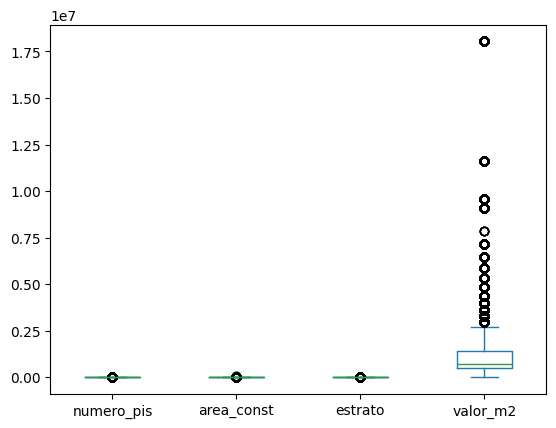

In [ ]:
data.plot(kind='box')

# 2. Preparación de Datos

In [4]:
#Se descartan datos atipicos que contienen areas de construcciones menores o iguales a cero
data = data[data['area_const'] > 0]
data

,id_constru,cbml,comuna,barrio,barrio_id,numero_pis,area_const,tipo_const,estrato,valor_m2
0,01011050019_0000,1011050019,1,1,01_01,1.0,41.44,N,2,271578.0
1,01011050003_0000,1011050003,1,1,01_01,1.0,64.18,N,2,271578.0
2,01011050027_0000,1011050027,1,1,01_01,2.0,40.80,N,2,271578.0
3,01011050026_0000,1011050026,1,1,01_01,1.0,26.14,N,2,271578.0
4,01010940145_0000,1010940145,1,1,01_01,1.0,2.48,N,2,271578.0
...,...,...,...,...,...,...,...,...,...,...
1094011,01040070012_0001,1040070012,1,4,01_04,2.0,9.40,N,2,363998.0
1094012,01040070012_0001,1040070012,1,4,01_04,1.0,3.83,N,2,363998.0
1094013,01040070012_0001,1040070012,1,4,01_04,3.0,242.88,N,2,363998.0
1094014,01040070029_0001,1040070029,1,4,01_04,1.0,8.49,N,2,363998.0


In [5]:
#Descartar variables irrelevantes

data = data.drop(columns=['id_constru', 'barrio', 'comuna','cbml','barrio_id'])


In [6]:
#Corregir tipos de datos
data['tipo_const']=data['tipo_const'].astype('category')



data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1082821 entries, 0 to 1094015
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype   
---  ------      --------------    -----   
 0   numero_pis  1082821 non-null  float64 
 1   area_const  1082821 non-null  float64 
 2   tipo_const  1082821 non-null  category
 3   estrato     1082821 non-null  int64   
 4   valor_m2    1082821 non-null  float64 
dtypes: category(1), float64(3), int64(1)
memory usage: 42.3 MB


In [7]:
# Se crean dummies para las variables predictoras categóricas
data = pd.get_dummies(data, columns=['tipo_const'], drop_first=False, dtype=int)
data.head()

,numero_pis,area_const,estrato,valor_m2,tipo_const_0,tipo_const_1,tipo_const_AL,tipo_const_B,tipo_const_BQ,tipo_const_C,...,tipo_const_E,tipo_const_FL,tipo_const_M,tipo_const_N,tipo_const_P,tipo_const_PQ,tipo_const_Q,tipo_const_TB,tipo_const_TO,tipo_const_ZC
0,1.0,41.44,2,271578.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,1.0,64.18,2,271578.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,2.0,40.80,2,271578.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,1.0,26.14,2,271578.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,1.0,2.48,2,271578.0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
#Se tienen todas las variables numericas, no fue necesario realizar label encoder para la variable objetivo que es el estrato
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1082821 entries, 0 to 1094015
Data columns (total 22 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   numero_pis     1082821 non-null  float64
 1   area_const     1082821 non-null  float64
 2   estrato        1082821 non-null  int64  
 3   valor_m2       1082821 non-null  float64
 4   tipo_const_0   1082821 non-null  int64  
 5   tipo_const_1   1082821 non-null  int64  
 6   tipo_const_AL  1082821 non-null  int64  
 7   tipo_const_B   1082821 non-null  int64  
 8   tipo_const_BQ  1082821 non-null  int64  
 9   tipo_const_C   1082821 non-null  int64  
 10  tipo_const_CA  1082821 non-null  int64  
 11  tipo_const_CD  1082821 non-null  int64  
 12  tipo_const_E   1082821 non-null  int64  
 13  tipo_const_FL  1082821 non-null  int64  
 14  tipo_const_M   1082821 non-null  int64  
 15  tipo_const_N   1082821 non-null  int64  
 16  tipo_const_P   1082821 non-null  int64  
 17  tipo_const_PQ

# 3. División 70-30

<Axes: xlabel='estrato'>

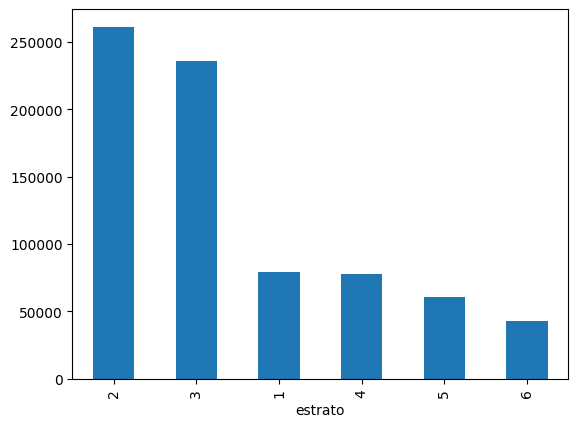

In [8]:
#División 70-30
from sklearn.model_selection import train_test_split
# Variables predictoras (X) - quitamos 'estrato'
X = data.drop('estrato', axis=1)
# Variable objetivo (y)
Y = data['estrato']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado
Y_train.value_counts().plot(kind='bar')

# **4. Aprendizaje con el 70% y Evaluación con el 30%**

# Tree
No se normaliza ya que se pierde interpretabilidad

In [9]:
#Modelo del 70%
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeClassifier #DecisionTreeRegressor

modelTree = DecisionTreeClassifier(criterion='gini', min_samples_leaf=20, max_depth=15)
modelTree.fit(X_train, Y_train) #70% train

DecisionTreeClassifier(max_depth=15, min_samples_leaf=20)

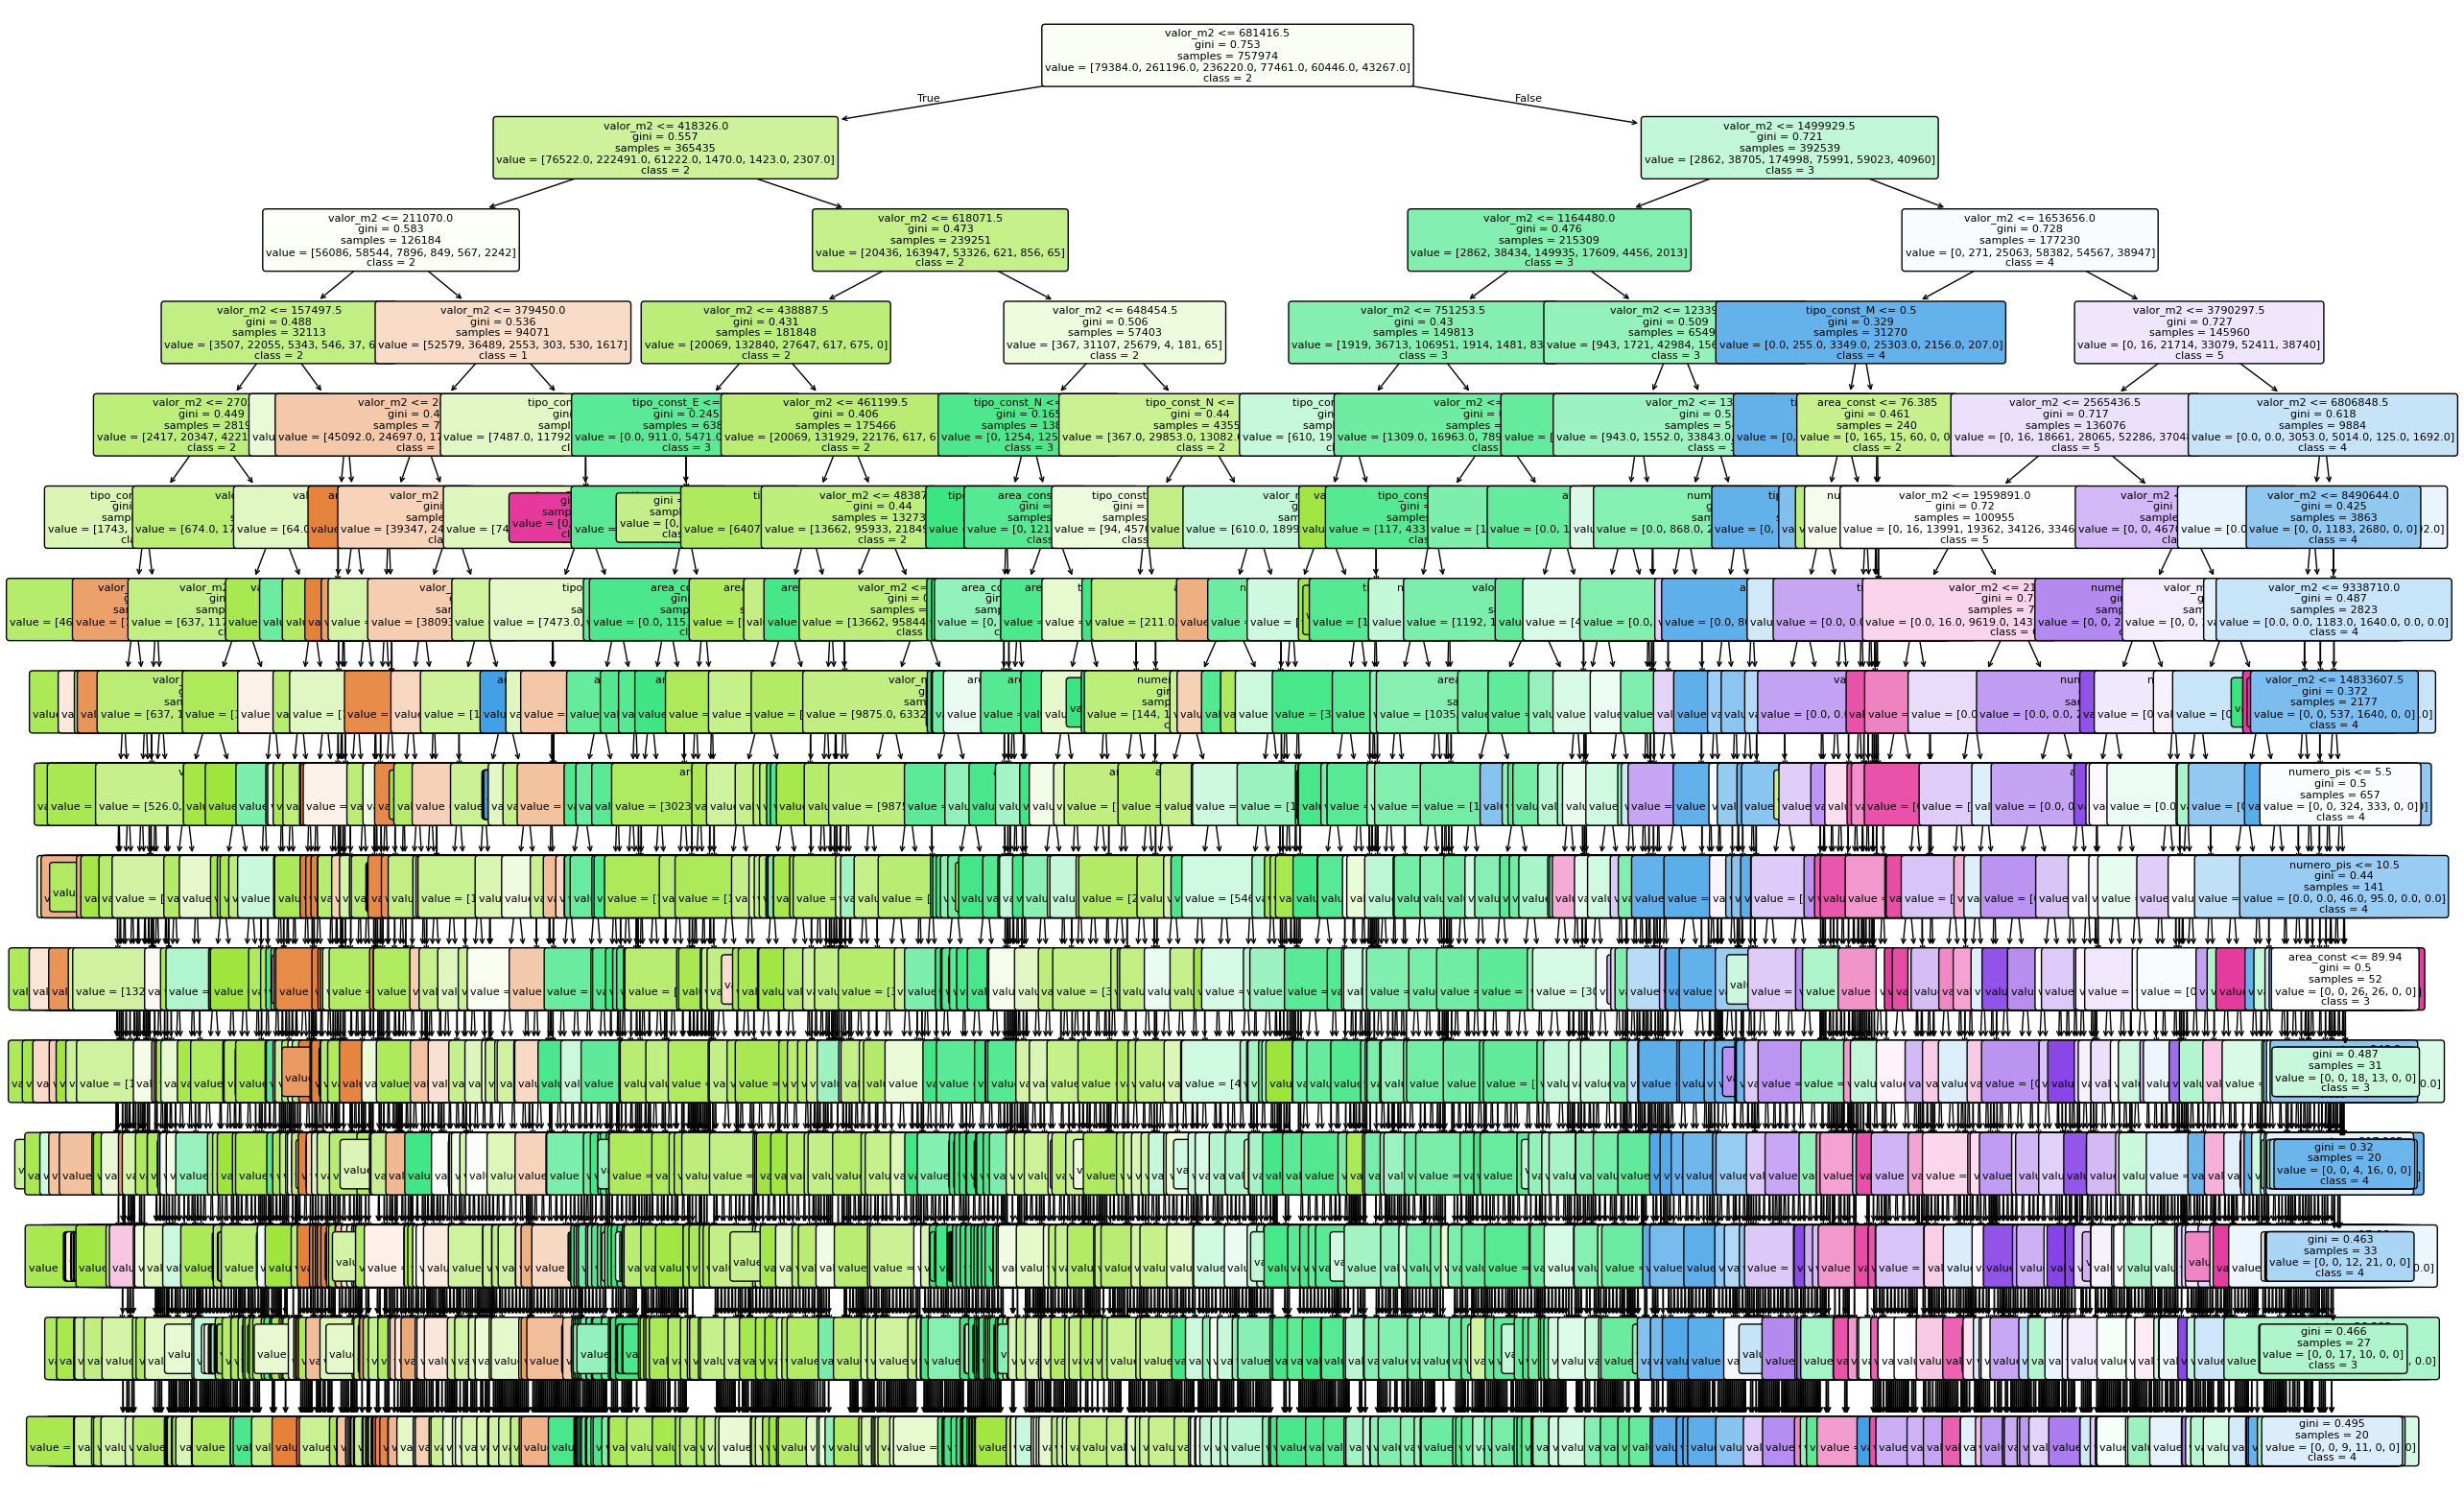

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20)) #Tamaño de la imagen
plot_tree(modelTree, feature_names=X_train.columns.values, class_names = [str(i) for i in sorted(Y.unique())], rounded=True,  fontsize=8, filled=True)
plt.show()

In [ ]:
#Evaluación 30% (X_test)
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30% Test
print(Y_pred)

[2 2 3 ... 3 3 5]


In [ ]:
#Exactitud. Correctos/Total
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.7146841436122237


In [ ]:
#Matriz de confusion
from sklearn import metrics

cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
cm


array([[19879, 13172,   960,     9,     0,     2],
       [ 7881, 88504, 15341,   124,    39,    53],
       [  161, 16515, 75566,  3533,  4119,  1343],
       [   25,   563,  7150, 16273,  6908,  2279],
       [    4,    91,  2287,  2114, 20529,   880],
       [    8,   299,  1082,  1107,  4635, 11412]])

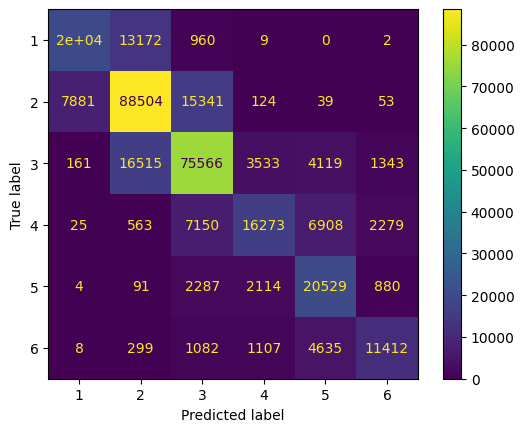

In [ ]:
#Plot de la matriz de confusion
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(Y.unique())
)

disp.plot()
plt.show()

In [ ]:
#Precision, Recall, f1, exactitud
#Aqui depende de la cantidad de datos, el "NO" tiene mucho mejor rendimiento por que tiene mas datos que "SI"
print(metrics.classification_report(
    y_true=Y_test,
    y_pred=Y_pred,
    target_names=[str(i) for i in sorted(Y.unique())]
))

              precision    recall  f1-score   support

           1       0.71      0.58      0.64     34022
           2       0.74      0.79      0.77    111942
           3       0.74      0.75      0.74    101237
           4       0.70      0.49      0.58     33198
           5       0.57      0.79      0.66     25905
           6       0.71      0.62      0.66     18543

    accuracy                           0.71    324847
   macro avg       0.70      0.67      0.67    324847
weighted avg       0.72      0.71      0.71    324847



# **KNN**

In [ ]:
#Normalizacion las variables numéricas (las dummies no se normalizan)
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
variables_numericas=['numero_pis', 'area_const', 'valor_m2']


min_max_scaler.fit(data[variables_numericas]) #Ajuste de los parametros sobre 100% de los datos (data): max - min

#Se aplica la normalización a 70%  y 30%
#LA TRANSFORMACION SE HACE SOBRE EL TRAIN
X_train[variables_numericas]= min_max_scaler.transform(X_train[variables_numericas]) #70%
X_test[variables_numericas]= min_max_scaler.transform(X_test[variables_numericas]) #30%
X_train.head()

,numero_pis,area_const,valor_m2,tipo_const_0,tipo_const_1,tipo_const_AL,tipo_const_B,tipo_const_BQ,tipo_const_C,tipo_const_CA,...,tipo_const_E,tipo_const_FL,tipo_const_M,tipo_const_N,tipo_const_P,tipo_const_PQ,tipo_const_Q,tipo_const_TB,tipo_const_TO,tipo_const_ZC
662710,0.076923,0.006188,0.032641,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
848769,0.102564,0.002740,0.058801,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
939564,0.076923,0.000031,0.078882,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
804730,0.025641,0.000037,0.043820,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
690083,0.025641,0.000640,0.019950,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
#Aprendizaje KNN con 70%
from sklearn.neighbors  import KNeighborsClassifier #KNeighborsRegressor

modelKnn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
modelKnn.fit(X_train, Y_train) #70%

KNeighborsClassifier(metric='euclidean')

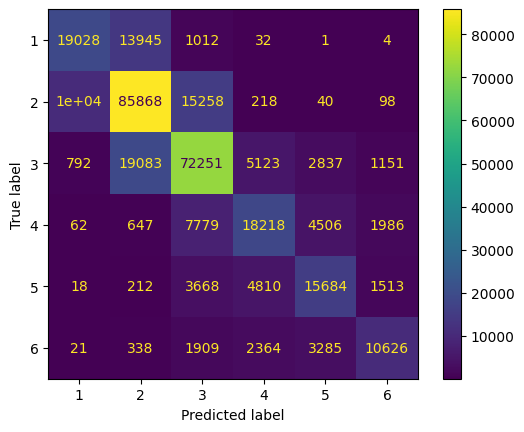

              precision    recall  f1-score   support

           1       0.63      0.56      0.59     34022
           2       0.72      0.77      0.74    111942
           3       0.71      0.71      0.71    101237
           4       0.59      0.55      0.57     33198
           5       0.60      0.61      0.60     25905
           6       0.69      0.57      0.63     18543

    accuracy                           0.68    324847
   macro avg       0.65      0.63      0.64    324847
weighted avg       0.68      0.68      0.68    324847



In [ ]:
# Evaluación de KNN con 30%
from sklearn import metrics
import matplotlib.pyplot as plt

Y_pred = modelKnn.predict(X_test)

# Nombres de clases
class_names = [str(i) for i in sorted(Y.unique())]

# Matriz de confusión
cm = metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot()
plt.show()

# Precision, Recall, f1, exactitud
print(metrics.classification_report(
    y_true=Y_test,
    y_pred=Y_pred,
    target_names=class_names
))

# **Red neuronal**

In [ ]:
#Red Neuronal

from sklearn.neural_network import MLPClassifier #MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
modelNN = MLPClassifier(activation="relu",hidden_layer_sizes=(100), learning_rate='adaptive',
                     learning_rate_init=0.001, momentum= 0.9, max_iter=1000, random_state=3)

modelNN.fit(X_train, Y_train) #70% normalizados

MLPClassifier(hidden_layer_sizes=100, learning_rate='adaptive', max_iter=1000,
              random_state=3)

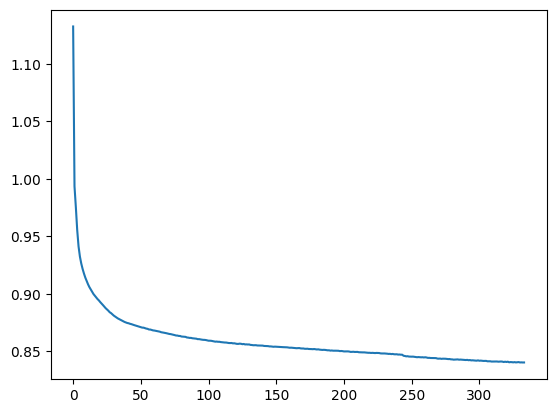

In [ ]:
#Loss es la desviación entre Y_train y el Y_pred
loss_values = modelNN.loss_curve_
plt.plot(loss_values)

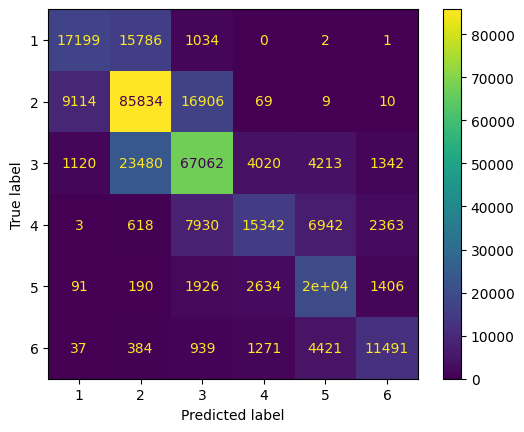

              precision    recall  f1-score   support

           1       0.62      0.51      0.56     34022
           2       0.68      0.77      0.72    111942
           3       0.70      0.66      0.68    101237
           4       0.66      0.46      0.54     33198
           5       0.56      0.76      0.64     25905
           6       0.69      0.62      0.65     18543

    accuracy                           0.67    324847
   macro avg       0.65      0.63      0.63    324847
weighted avg       0.67      0.67      0.66    324847



In [ ]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Nombres de clases
class_names = [str(i) for i in sorted(Y.unique())]

Y_pred = modelNN.predict(X_test)

# Matriz de confusión
cm = metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot()
plt.show()

# Precision, Recall, f1, exactitud
print(metrics.classification_report(
    y_true=Y_test,
    y_pred=Y_pred,
    target_names=class_names
))

# **Regresión Logistica**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Creación del modelo de Regresión Logística
modelLR = LogisticRegression(max_iter=500, random_state=3)
modelLR.fit(X_train, Y_train) # 70% normalizados

LogisticRegression(max_iter=500, random_state=3)

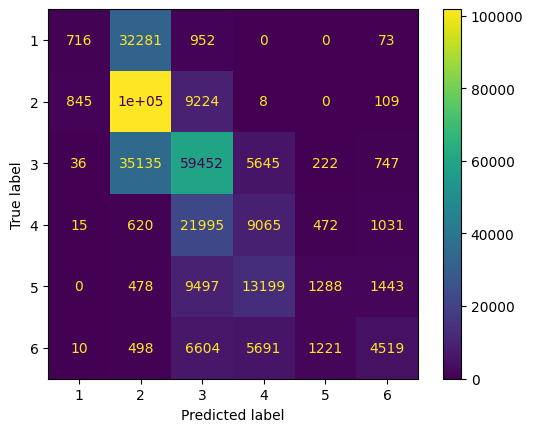

              precision    recall  f1-score   support

           1       0.44      0.02      0.04     34022
           2       0.60      0.91      0.72    111942
           3       0.55      0.59      0.57    101237
           4       0.27      0.27      0.27     33198
           5       0.40      0.05      0.09     25905
           6       0.57      0.24      0.34     18543

    accuracy                           0.54    324847
   macro avg       0.47      0.35      0.34    324847
weighted avg       0.52      0.54      0.48    324847



In [ ]:
# Evaluación de Regresión Logística
Y_pred = modelLR.predict(X_test)

# Matriz de confusión
cm = metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp = metrics.ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot()
plt.show()

# Precision, Recall, f1, exactitud
print(metrics.classification_report(
    y_true=Y_test,
    y_pred=Y_pred,
    target_names=class_names
))

In [10]:
# Entrenar modelo final con el 100% de los datos
modelTree.fit(X, Y)

# Guardar modelo
import pickle

filename = 'modelo_arbol.pkl'
variables = X.columns.values

pickle.dump(
    [modelTree, variables],
    open(filename, 'wb')
)